In [1]:
import pandas as pd

In [3]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns

In [11]:
#Cargamos dataset de ventas
dfVentas = pd.read_csv("ventas-por-factura.csv")

In [15]:
#se cargan dataset sucio
dfVentas.shape

(25953, 6)

In [17]:
dfVentas.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [19]:
dfVentas.tail()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"
25949,553060,5/13/2021 10:44:00,15826.0,United Kingdom,488,"720,00"
25950,577049,11/17/2021 13:58:00,17397.0,United Kingdom,104,"298,78"
25951,550122,4/14/2021 12:39:00,12931.0,United Kingdom,1176,"1488,00"
25952,537999,12/9/2020 11:44:00,NaN,United Kingdom,-223,"0,00"


In [21]:
dfVentas.describe()

,ID Cliente,Cantidad
count,22229.000000,25953.000000
mean,15238.289892,199.474049
std,1732.981685,1107.075809
min,12346.000000,-80995.000000
25%,13755.000000,6.000000
50%,15136.000000,100.000000
75%,16746.000000,240.000000
max,18287.000000,80995.000000


In [23]:
dfVentas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25953 non-null  object 
 1   Fecha de factura  25953 non-null  object 
 2   ID Cliente        22229 non-null  float64
 3   País              25953 non-null  object 
 4   Cantidad          25953 non-null  int64  
 5   Monto             25953 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.2+ MB


In [27]:
#Generamos una copia "por cualquier cosa"
dfVentas = dfVentas.copy()

In [29]:
dfVentas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25953 non-null  object 
 1   Fecha de factura  25953 non-null  object 
 2   ID Cliente        22229 non-null  float64
 3   País              25953 non-null  object 
 4   Cantidad          25953 non-null  int64  
 5   Monto             25953 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.2+ MB


<function matplotlib.pyplot.show(close=None, block=None)>

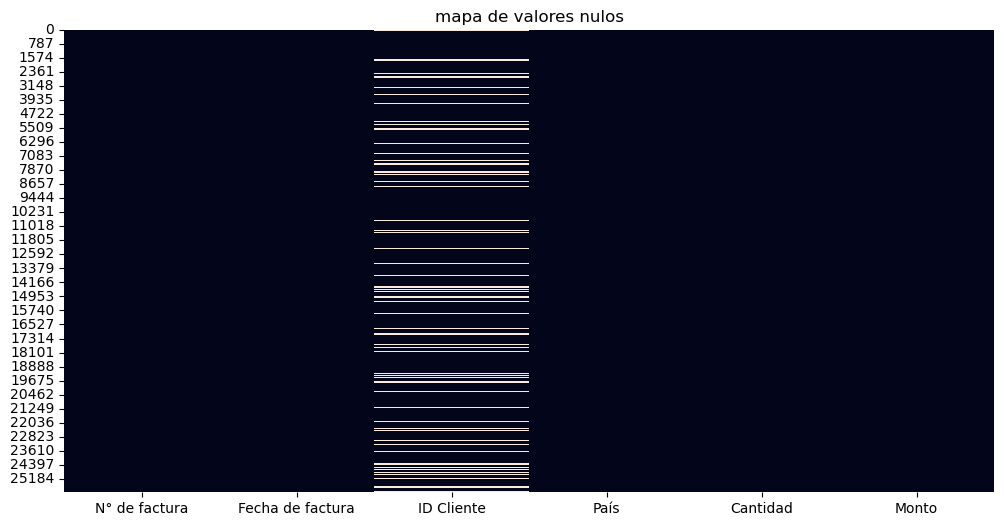

In [33]:
plt.figure(figsize = (12,6 ))
sns.heatmap(dfVentas.isnull(), cbar = False)
plt.title("mapa de valores nulos")
plt.show

In [39]:
#Limpieza de datos
dfVentas.duplicated().sum()

0

In [37]:
dfVentas.drop_duplicates(inplace=True)

In [41]:
#Verificamos la limpieza de datos
dfVentas.duplicated().sum()

0

In [43]:
dfClean = dfVentas.copy()

In [45]:
#Corregir formato de texto a numérico en Monto
dfClean['Monto'] = dfClean['Monto'].str.replace(',', '.').astype(float)

In [47]:
#Corregir formato de texto a fecha real
dfClean['Fecha de factura'] = pd.to_datetime(dfClean['Fecha de factura'])

In [49]:
#Eliminar los valores negativos y ceros (Anomalías/Outliers)
dfClean = dfClean[(dfClean['Cantidad'] > 0) & (dfClean['Monto'] > 0)]

In [51]:
#Tratar nulos en ID Cliente asignando 0 y quitando el .0 decimal
dfClean['ID Cliente'] = dfClean['ID Cliente'].fillna(0).astype(int)

In [53]:
#Remover registros duplicados en caso de existir
dfClean = dfClean.drop_duplicates()

In [57]:
#Verificar si hay nulos
dfClean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20002 entries, 0 to 25951
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   N° de factura     20002 non-null  object        
 1   Fecha de factura  20002 non-null  datetime64[ns]
 2   ID Cliente        20002 non-null  int32         
 3   País              20002 non-null  object        
 4   Cantidad          20002 non-null  int64         
 5   Monto             20002 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(2)
memory usage: 1015.7+ KB


In [59]:
#Exportar el DataFrame limpio a la carpeta DataSet con el formato CSV
dfClean.to_csv("DataSet/ventas-por-factura-limpio.csv", index=False)

# Conclusiones del Laboratorio 07

# Justificación
1. Monto: Se corrigió el formato de texto a numérico continuo sustituyendo las comas por puntos para que fuera posible realizar operaciones matemáticas.
2. ID Cliente:Los valores faltantes se imputaron con un `0` genérico para no perder el rastro financiero de esas facturas, eliminando los decimales flotantes.
3. Filtro de Positivos: Se eliminaron cantidades y montos menores o iguales a cero, interpretándolos como registros erróneos o devoluciones/cancelaciones.

# Impacto del principio GIGO
El principio GIGO establece que la calidad del resultado de cualquier análisis o modelo de Machine Learning depende enteramente de la calidad de los datos de entrada. 
Si hubiéramos procesado o entrenado un modelo predictivo con los datos "sucios" originales los cuales contenían registros atípicos extremos como la cantidad negativa o los montos interpretados erróneamente como texto las predicciones de ventas futuras o las distribuciones por país habrían arrojado resultados completamente sesgados, inválidos y perjudiciales para la toma de decisiones del negocio.
Por lo tanto, el proceso de limpieza y transformación ejecutado es mandatorio para garantizar análisis fiables.